# Setup and Initialization

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr

## Loading the Tennessee Eastman Process (TEP) Data

In [2]:
import os

base_path = r"../data/raw/"

#loading only the training data for eda
files = {
    "train_nonfaulty": "TEP_FaultFree_Training.RData",    
    "train_faulty": "TEP_Faulty_Training.RData"
}

df = {}

for key, filename in files.items():  
    full_path = os.path.join(base_path, filename)
    # load the RData file 
    # Pyreadr is used to efficiently parse .RData files into pandas DataFrames without needing an R environment.
    try:               
        result = pyreadr.read_r(full_path) 
        # result is a dictionary where the key is usually the internal R variable name and the first object available  is our df        
        df_name = list(result.keys())[0]        
        df[key] = result[df_name]                
        print(f"loaded {key}: {df[key].shape}")
    except FileNotFoundError:        
        print(f"Error: {filename}.") 
        
df_train_nonfaulty = df.get("train_nonfaulty") 
df_train_faulty = df.get("train_faulty")

loaded train_nonfaulty: (250000, 55)
loaded train_faulty: (5000000, 55)


In [3]:
df_train_nonfaulty.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


In [4]:
df_train_nonfaulty.head()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530
3,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,...,53.946,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089
4,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,...,53.658,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461


# Data Inspection

In [5]:
df_train_nonfaulty.describe()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,250000.0,250000.000000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,0.0,250.500000,250.500000,0.250482,3663.785706,4508.81979,9.347101,26.902196,42.337598,2705.037865,...,53.973668,24.639472,61.298501,22.216644,40.055456,38.098898,46.534295,47.958591,41.104304,18.118706
std,0.0,144.337567,144.337567,0.030873,34.006357,39.21542,0.085721,0.211485,0.218513,7.525596,...,0.469663,3.037743,1.243805,0.530156,1.526751,2.965266,2.351304,2.716520,0.540817,1.463678
min,0.0,1.000000,1.000000,0.122450,3511.800000,4336.90000,8.972700,25.951000,41.394000,2672.300000,...,52.095000,11.977000,55.961000,19.749000,33.389000,25.959000,36.937000,36.641000,38.586000,11.705000
25%,0.0,125.750000,125.750000,0.229770,3640.800000,4482.40000,9.289300,26.758000,42.188000,2700.100000,...,53.657000,22.602000,60.453000,21.864000,39.021000,36.081000,44.931000,46.265000,40.740000,17.130000
50%,0.0,250.500000,250.500000,0.250510,3663.700000,4508.80000,9.347100,26.902000,42.338000,2705.000000,...,53.974000,24.644000,61.298000,22.217000,40.058000,38.091000,46.530000,47.820000,41.104000,18.119000
75%,0.0,375.250000,375.250000,0.271200,3686.800000,4535.30000,9.405100,27.046000,42.487000,2710.000000,...,54.290000,26.674000,62.144000,22.568000,41.084000,40.117000,48.140000,49.651000,41.470000,19.111000
max,0.0,500.000000,500.000000,0.391740,3808.400000,4683.70000,9.729800,27.818000,43.257000,2739.100000,...,56.118000,38.351000,66.443000,24.525000,47.498000,50.729000,56.443000,59.616000,43.930000,24.762000


In [6]:
df_train_faulty.describe()

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,...,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.050000e+01,2.505000e+02,2.505000e+02,2.613588e-01,3.663777e+03,4.506046e+03,9.370345e+00,2.690156e+01,4.236419e+01,2.723005e+03,...,5.431755e+01,3.043177e+01,6.324830e+01,2.295485e+01,3.992297e+01,3.807265e+01,4.643742e+01,5.060598e+01,4.194845e+01,1.884376e+01
std,5.766282e+00,1.443373e+02,1.443373e+02,1.495384e-01,4.316941e+01,1.110368e+02,3.646151e-01,2.320034e-01,3.172128e-01,7.599384e+01,...,5.258092e+00,2.048365e+01,7.400080e+00,1.108258e+01,1.293348e+01,2.949138e+00,2.358468e+00,1.759840e+01,1.001227e+01,5.176705e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,-4.735000e-03,3.327400e+03,3.540700e+03,6.639900e+00,2.538600e+01,3.965600e+01,2.413800e+03,...,3.118400e+01,-2.718600e-01,-4.893100e-03,-9.941000e-02,0.000000e+00,2.280100e+01,3.492300e+01,-3.635500e-01,-2.809500e-01,-5.327000e-03
25%,5.750000e+00,1.257500e+02,1.257500e+02,2.183000e-01,3.636500e+03,4.469000e+03,9.264200e+00,2.676000e+01,4.218100e+01,2.697600e+03,...,5.349700e+01,2.228000e+01,6.031400e+01,2.142300e+01,3.831300e+01,3.604900e+01,4.487800e+01,4.547900e+01,4.057500e+01,1.714300e+01
50%,1.050000e+01,2.505000e+02,2.505000e+02,2.511300e-01,3.663300e+03,4.508500e+03,9.355200e+00,2.690100e+01,4.234800e+01,2.705600e+03,...,5.397000e+01,2.521500e+01,6.149900e+01,2.212900e+01,3.996700e+01,3.815000e+01,4.633900e+01,4.806500e+01,4.120600e+01,1.829500e+01
75%,1.525000e+01,3.752500e+02,3.752500e+02,2.832100e-01,3.690200e+03,4.548000e+03,9.456800e+00,2.704300e+01,4.252400e+01,2.715000e+03,...,5.444300e+01,2.879700e+01,6.284100e+01,2.273800e+01,4.150700e+01,3.999100e+01,4.803100e+01,5.188700e+01,4.194900e+01,1.953700e+01
max,2.000000e+01,5.000000e+02,5.000000e+02,1.017500e+00,3.906700e+03,5.175800e+03,1.224000e+01,2.848600e+01,4.465300e+01,3.000500e+03,...,1.000000e+02,1.001900e+02,1.000200e+02,1.001100e+02,9.752800e+01,5.312100e+01,5.998000e+01,1.005200e+02,1.003200e+02,1.000100e+02


## Data Quality Checks (Missing & Duplicates)

In [7]:
df_train_nonfaulty.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 55 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   faultNumber    250000 non-null  float64
 1   simulationRun  250000 non-null  float64
 2   sample         250000 non-null  int32  
 3   xmeas_1        250000 non-null  float64
 4   xmeas_2        250000 non-null  float64
 5   xmeas_3        250000 non-null  float64
 6   xmeas_4        250000 non-null  float64
 7   xmeas_5        250000 non-null  float64
 8   xmeas_6        250000 non-null  float64
 9   xmeas_7        250000 non-null  float64
 10  xmeas_8        250000 non-null  float64
 11  xmeas_9        250000 non-null  float64
 12  xmeas_10       250000 non-null  float64
 13  xmeas_11       250000 non-null  float64
 14  xmeas_12       250000 non-null  float64
 15  xmeas_13       250000 non-null  float64
 16  xmeas_14       250000 non-null  float64
 17  xmeas_15       250000 non-null  float64


In [8]:
df_train_faulty.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 55 columns):
 #   Column         Dtype  
---  ------         -----  
 0   faultNumber    int32  
 1   simulationRun  float64
 2   sample         int32  
 3   xmeas_1        float64
 4   xmeas_2        float64
 5   xmeas_3        float64
 6   xmeas_4        float64
 7   xmeas_5        float64
 8   xmeas_6        float64
 9   xmeas_7        float64
 10  xmeas_8        float64
 11  xmeas_9        float64
 12  xmeas_10       float64
 13  xmeas_11       float64
 14  xmeas_12       float64
 15  xmeas_13       float64
 16  xmeas_14       float64
 17  xmeas_15       float64
 18  xmeas_16       float64
 19  xmeas_17       float64
 20  xmeas_18       float64
 21  xmeas_19       float64
 22  xmeas_20       float64
 23  xmeas_21       float64
 24  xmeas_22       float64
 25  xmeas_23       float64
 26  xmeas_24       float64
 27  xmeas_25       float64
 28  xmeas_26       float64
 29  xmeas_27       float64
 3

In [9]:
print("Number of missing values in Non-Faulty Training:", df_train_nonfaulty.isnull().sum()) 
print("Number of missing values in Faulty Training:", df_train_faulty.isnull().sum())

Number of missing values in Non-Faulty Training: faultNumber      0
simulationRun    0
sample           0
xmeas_1          0
xmeas_2          0
xmeas_3          0
xmeas_4          0
xmeas_5          0
xmeas_6          0
xmeas_7          0
xmeas_8          0
xmeas_9          0
xmeas_10         0
xmeas_11         0
xmeas_12         0
xmeas_13         0
xmeas_14         0
xmeas_15         0
xmeas_16         0
xmeas_17         0
xmeas_18         0
xmeas_19         0
xmeas_20         0
xmeas_21         0
xmeas_22         0
xmeas_23         0
xmeas_24         0
xmeas_25         0
xmeas_26         0
xmeas_27         0
xmeas_28         0
xmeas_29         0
xmeas_30         0
xmeas_31         0
xmeas_32         0
xmeas_33         0
xmeas_34         0
xmeas_35         0
xmeas_36         0
xmeas_37         0
xmeas_38         0
xmeas_39         0
xmeas_40         0
xmeas_41         0
xmv_1            0
xmv_2            0
xmv_3            0
xmv_4            0
xmv_5            0
xmv_6            0
x

In [10]:
print("Number of duplicate rows in Non-Faulty Training:", df_train_nonfaulty.duplicated().sum())
print("Number of duplicate rows in Faulty Training:", df_train_faulty.duplicated().sum())

Number of duplicate rows in Non-Faulty Training: 0
Number of duplicate rows in Faulty Training: 0


*Insight: The data is clean with no missing or duplicate values.*

# Target Variable Analysis

In [11]:
# Check for Class Imbalance
count_nonfaulty = len(df_train_nonfaulty) 
count_faulty = len(df_train_faulty)
print("Number of faulty rows:", count_faulty)
print("Number of non-faulty rows:", count_nonfaulty)

Number of faulty rows: 5000000
Number of non-faulty rows: 250000


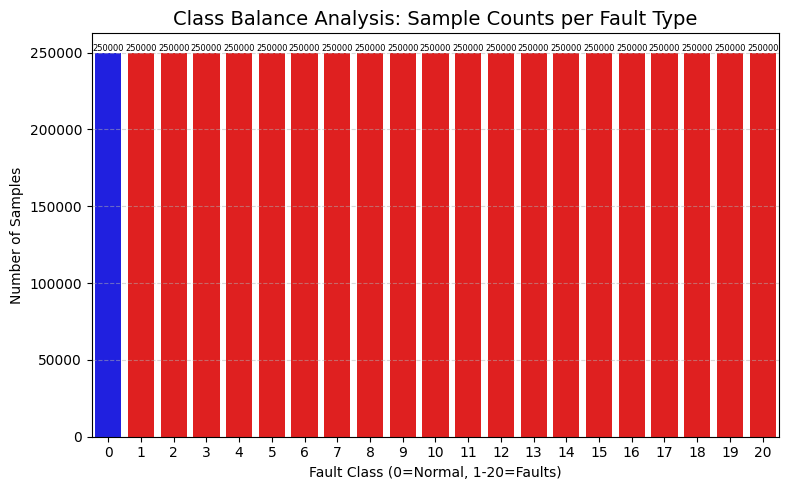

In [12]:
fault_counts = df_train_faulty['faultNumber'].value_counts().sort_index() 
counts_dict = {0: count_nonfaulty} 
counts_dict.update(fault_counts.to_dict())
df_counts = pd.DataFrame(list(counts_dict.items()), columns=['Fault ID', 'Sample Count']) 

plt.figure(figsize=(8, 5))  
# highlighting normal state (0) in blue and all faulty states (1-20) in red to visualize the severe class imbalance typical in industrial fault detection.
colors = ['blue' if x == 0 else 'red' for x in df_counts['Fault ID']] 
sns.barplot(data=df_counts, x='Fault ID', y='Sample Count', palette=colors,hue='Fault ID', dodge=False, legend=False) 
plt.title('Class Balance Analysis: Sample Counts per Fault Type', fontsize=14) 
plt.ylabel('Number of Samples') 
plt.xlabel('Fault Class (0=Normal, 1-20=Faults)') 
# precise numbers on top of bars 
plt.grid(axis='y', linestyle='--', alpha=0.5) 

for i, v in enumerate(df_counts['Sample Count']):    
    plt.text(i, v, str(v), ha='center', va='bottom', fontsize=6) 

plt.tight_layout()
plt.show()

*Insight: The count of faulty and non-faulty data rows shows a very high class imbalance. On investigating further, it is seen that although there is a very high imbalance in target variable counts (0 for non-faulty and 1 for faulty) but the distribution of classes from 0-20 (0 for non-faulty and 1-20 for different classes) is perfectly balanced. We have the same number of samples for each fault. Hence, we can run analysis on each fault one by one individually.*

# Outlier Detection (Fault 20)
In industrial datasets, anomalies often manifest as extreme values. We will use the Interquartile Range (IQR) method to identify which sensors experience the most extreme deviations during a specific fault state (e.g., Fault 20).


In [13]:
def count_outliers(series):    
    Q1 = series.quantile(0.25)    
    Q3 = series.quantile(0.75)    
    IQR = Q3 - Q1  
    
    # std deviation : anything outside 1.5 * IQR is an outlier    
    lower_bound = Q1 - 1.5 * IQR    
    upper_bound = Q3 + 1.5 * IQR        
    
    # counts how many points fall outside these bounds    
    return ((series < lower_bound) | (series > upper_bound)).sum()

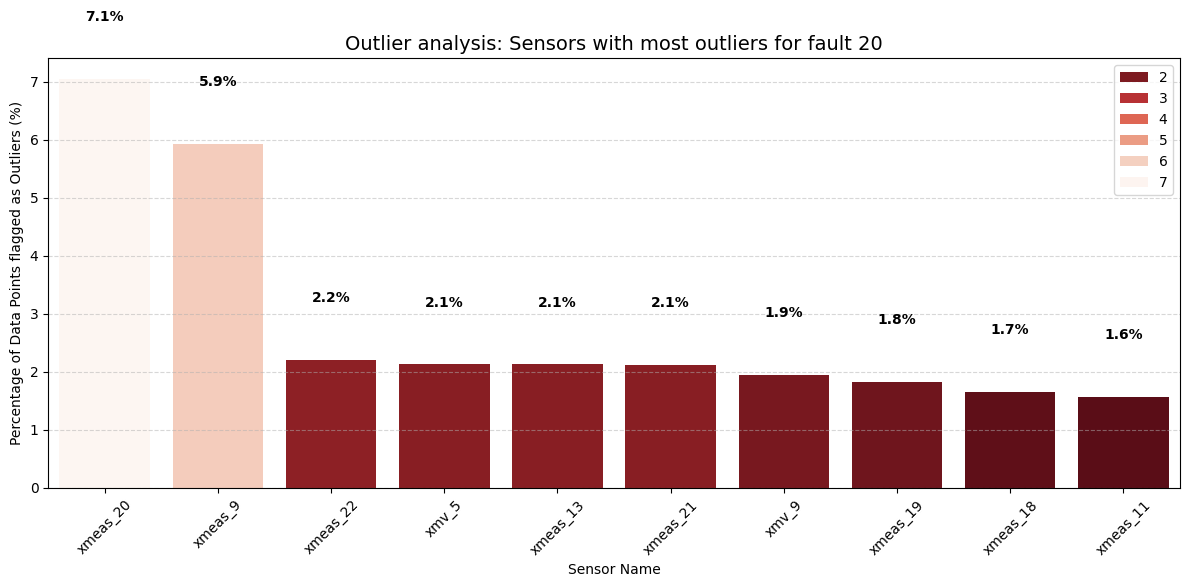

Top 5 Sensors with most outliers in Fault 20:
xmeas_20    7.0508
xmeas_9     5.9348
xmeas_22    2.2076
xmv_5       2.1276
xmeas_13    2.1260
dtype: float64


In [14]:
# applying this to ALL 52 columns in the Faulty Dataset for fault 20 
fault_20_data = df_train_faulty[df_train_faulty['faultNumber'] == 20].drop(columns=['faultNumber', 'simulationRun', 'sample']) 

outlier_counts = fault_20_data.apply(count_outliers) 
# calculating the percentage of outliers 
outlier_pct = (outlier_counts / len(fault_20_data)) * 100 

# sorting and visualize the top 10 sensors with the most outliers 
top_outliers = outlier_pct.sort_values(ascending=False).head(10) 
plt.figure(figsize=(12, 6)) 
sns.barplot(x=top_outliers.index, y=top_outliers.values, palette='Reds_r',hue=top_outliers.values) 
plt.title('Outlier analysis: Sensors with most outliers for fault 20', fontsize=14) 
plt.ylabel('Percentage of Data Points flagged as Outliers (%)') 
plt.xlabel('Sensor Name') 
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.5) 

# adding value labels on top 
for i, v in enumerate(top_outliers.values):    
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold') 
    
plt.tight_layout()
plt.show() 
    
print("Top 5 Sensors with most outliers in Fault 20:") 
print(top_outliers.head(5))

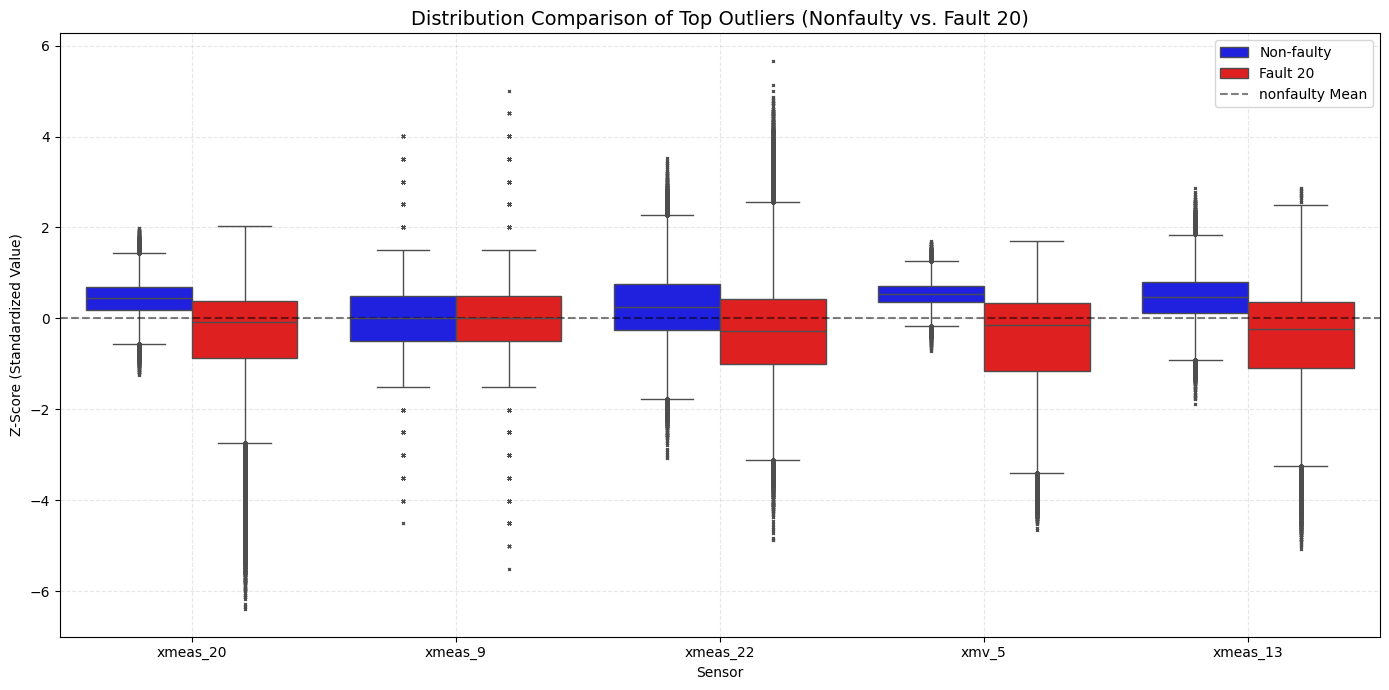

In [15]:
from sklearn.preprocessing import StandardScaler

top_sensor_names = top_outliers.head(5).index.tolist() 
nonfaulty_subset = df_train_nonfaulty[top_sensor_names].copy() 
nonfaulty_subset['Condition'] = 'Non-faulty' 
faulty_subset = df_train_faulty[(df_train_faulty['faultNumber'] == 20)][top_sensor_names].copy() 
faulty_subset['Condition'] = 'Fault 20' 
combined_df = pd.concat([nonfaulty_subset, faulty_subset]) 

# Scaling the data for visualization
# We only scale the numeric columns (not the 'Condition' label) 
scaler = StandardScaler() 
numeric_cols = combined_df.select_dtypes(include=['float64', 'int64']).columns 
combined_df[numeric_cols] = scaler.fit_transform(combined_df[numeric_cols]) 
df_melted = combined_df.melt(id_vars='Condition', var_name='Sensor', value_name='Z-Score (Standardized Value)') 

plt.figure(figsize=(14, 7)) 
sns.boxplot(data=df_melted, x='Sensor', y='Z-Score (Standardized Value)', hue='Condition', palette=['blue', 'red'], flierprops={"marker": "x", "markersize": 2}) 
plt.title('Distribution Comparison of Top Outliers (Nonfaulty vs. Fault 20)', fontsize=14) 
plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='nonfaulty Mean') 
plt.grid(True, linestyle='--', alpha=0.3) 
plt.legend() 
plt.tight_layout() 
plt.show()

*Insight: The outlier analysis reveals which specific parts of the chemical process are physically breaking down during Fault 20. The boxplot further confirms that the distribution of these sensors varies for non-faulty and faulty readings.*

# Univariate Analysis (Skewness Check)
Process variables usually follow a normal distribution. High skewness indicates a systemic bias or a saturated sensor.

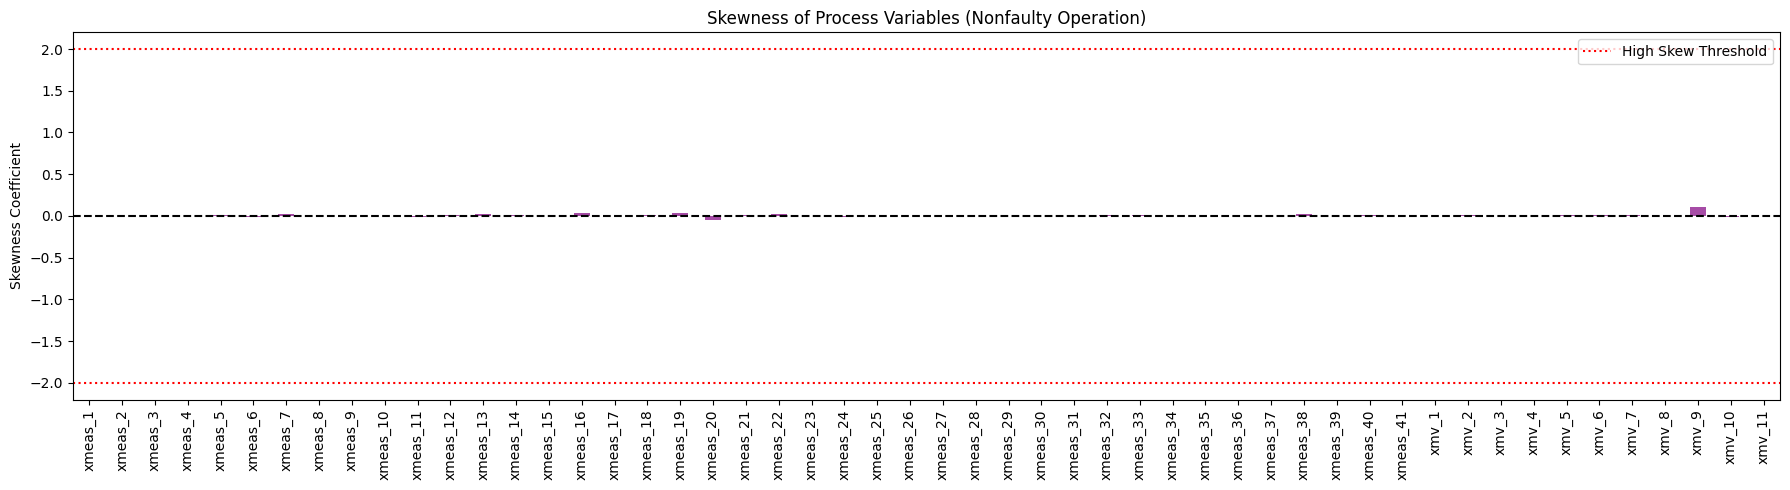

Highly Skewed Variables (>2):
[]


In [16]:
# Calculate Skewness for Normal Data 
skewness = df_train_nonfaulty.drop(columns=['faultNumber', 'simulationRun', 'sample']).skew() 
plt.figure(figsize=(18, 5)) 
skewness.plot(kind='bar', color='purple', alpha=0.7) 
plt.title('Skewness of Process Variables (Nonfaulty Operation)')
plt.ylabel('Skewness Coefficient') 
plt.axhline(0, color='black', linestyle='--') 
plt.axhline(2, color='red', linestyle=':', label='High Skew Threshold') 
plt.axhline(-2, color='red', linestyle=':') 
plt.legend() 
plt.tight_layout() 
plt.show() 
print("Highly Skewed Variables (>2):") 
print(skewness[abs(skewness) > 2].index.tolist())

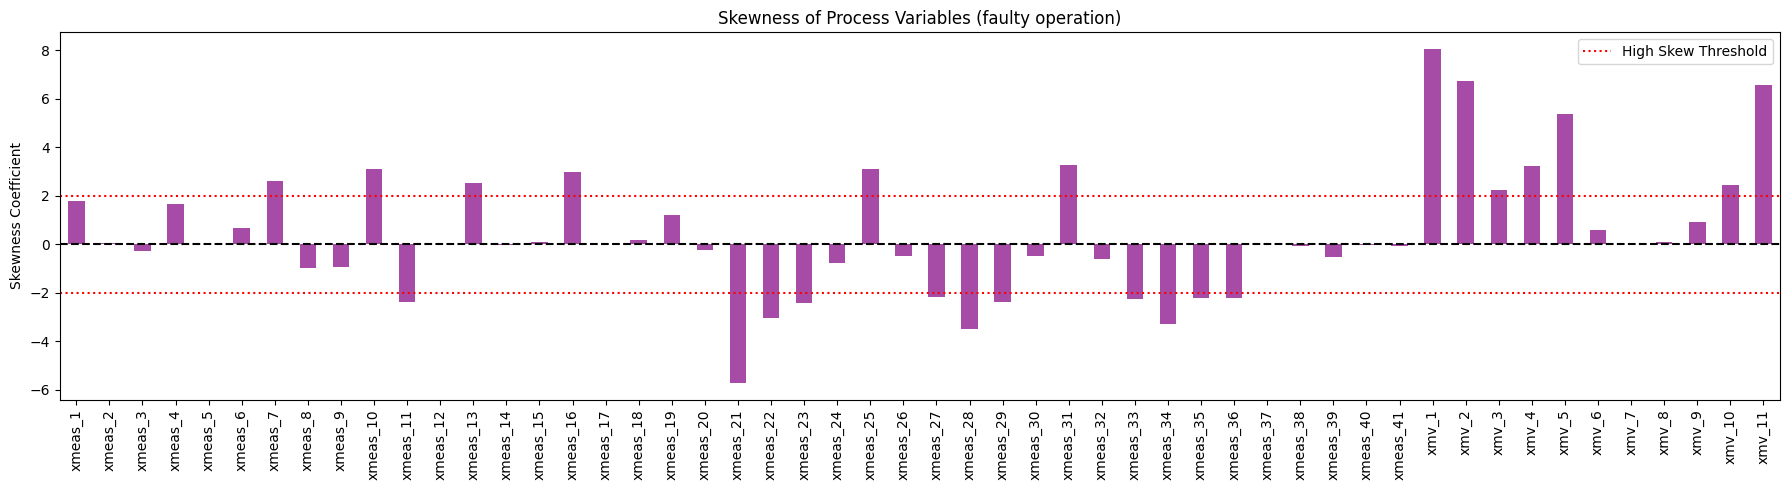

Highly Skewed Variables (>2):
['xmeas_7', 'xmeas_10', 'xmeas_11', 'xmeas_13', 'xmeas_16', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_25', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_31', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_10', 'xmv_11']


In [17]:
# Calculate Skewness for faulty Data 
skewness = df_train_faulty.drop(columns=['faultNumber', 'simulationRun', 'sample']).skew() 
plt.figure(figsize=(18, 5)) 
skewness.plot(kind='bar', color='purple', alpha=0.7) 
plt.title('Skewness of Process Variables (faulty operation)') 
plt.ylabel('Skewness Coefficient') 
plt.axhline(0, color='black', linestyle='--') 
plt.axhline(2, color='red', linestyle=':', label='High Skew Threshold') 
plt.axhline(-2, color='red', linestyle=':') 
plt.legend() 
plt.tight_layout() 
plt.show() 
print("Highly Skewed Variables (>2):") 
print(skewness[abs(skewness) > 2].index.tolist())

*Insight: In the non-faulty data, there are not any skewed variables. However, in the faulty data, half of the variables are skewed.*

# Multivariate Analysis
## Correlation Breakdown (The "Damage" Map)
In a complex chemical process, sensors are highly correlated (e.g., as temperature rises, pressure rises). A fault often breaks these physical relationships. By subtracting the faulty correlation matrix from the normal correlation matrix, we can visualize the structural breakdown of the system.

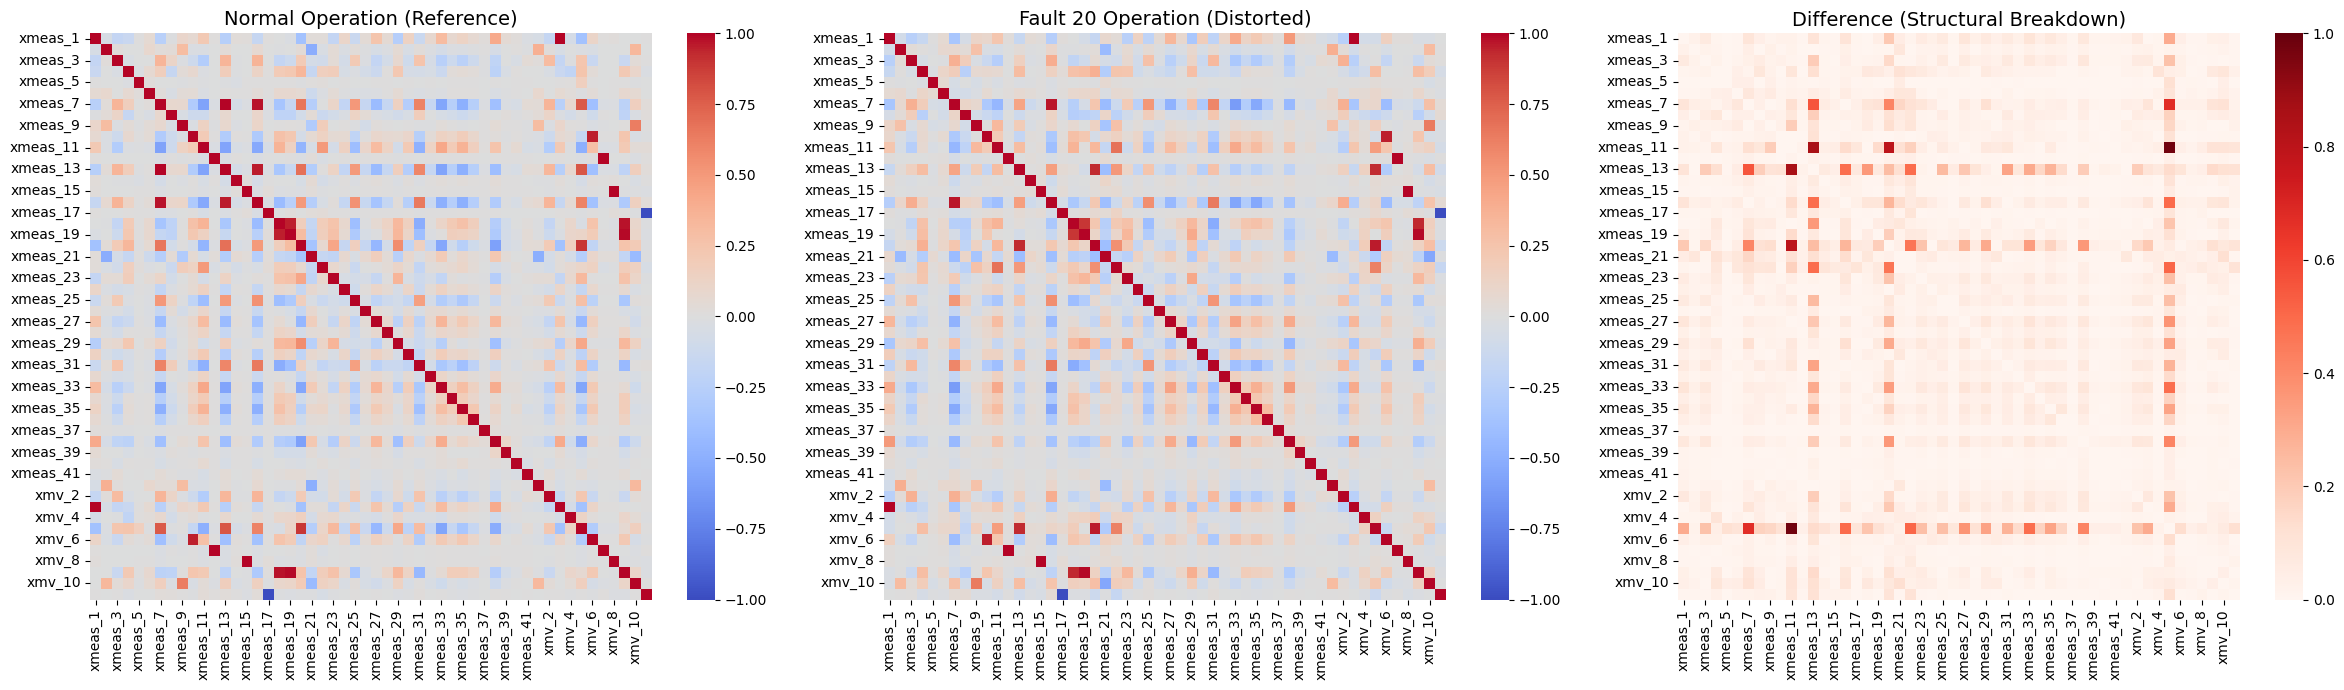

In [18]:
# Remove ID columns to ensure we only correlate actual sensor readings
drop_cols = ['faultNumber', 'simulationRun', 'sample'] 
df_nonfaulty_clean = df_train_nonfaulty.drop(columns=drop_cols, errors='ignore') 
df_faulty_clean = df_train_faulty[df_train_faulty['faultNumber'] == 20].drop(columns=drop_cols, errors='ignore') 

# Calculate correlation matrices 
corr_normal = df_nonfaulty_clean.corr() 
corr_faulty = df_faulty_clean.corr() 

# Calculate the "Breakdown" (Absolute Difference)
corr_diff = abs(corr_normal - corr_faulty) 

fig, axes = plt.subplots(1, 3, figsize=(24, 7)) 

# Plot 1: Normal State 
sns.heatmap(corr_normal, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1) 
axes[0].set_title('Normal Operation (Reference)', fontsize=14) 

# Plot 2: Faulty State 
sns.heatmap(corr_faulty, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1) 
axes[1].set_title('Fault 20 Operation (Distorted)', fontsize=14) 

# Plot 3: The Difference Map 
sns.heatmap(corr_diff, ax=axes[2], cmap='Reds', vmin=0, vmax=1) 
axes[2].set_title('Difference (Structural Breakdown)', fontsize=14) 

plt.tight_layout() 
plt.show()

*Insight: The difference map vividly highlights the specific sensor pairs whose physical relationships are destroyed during Fault 20.*

## Fault Signature Matrix
To understand how different faults affect the system holistically, we can calculate the percentage deviation of every sensor across all 20 fault types.

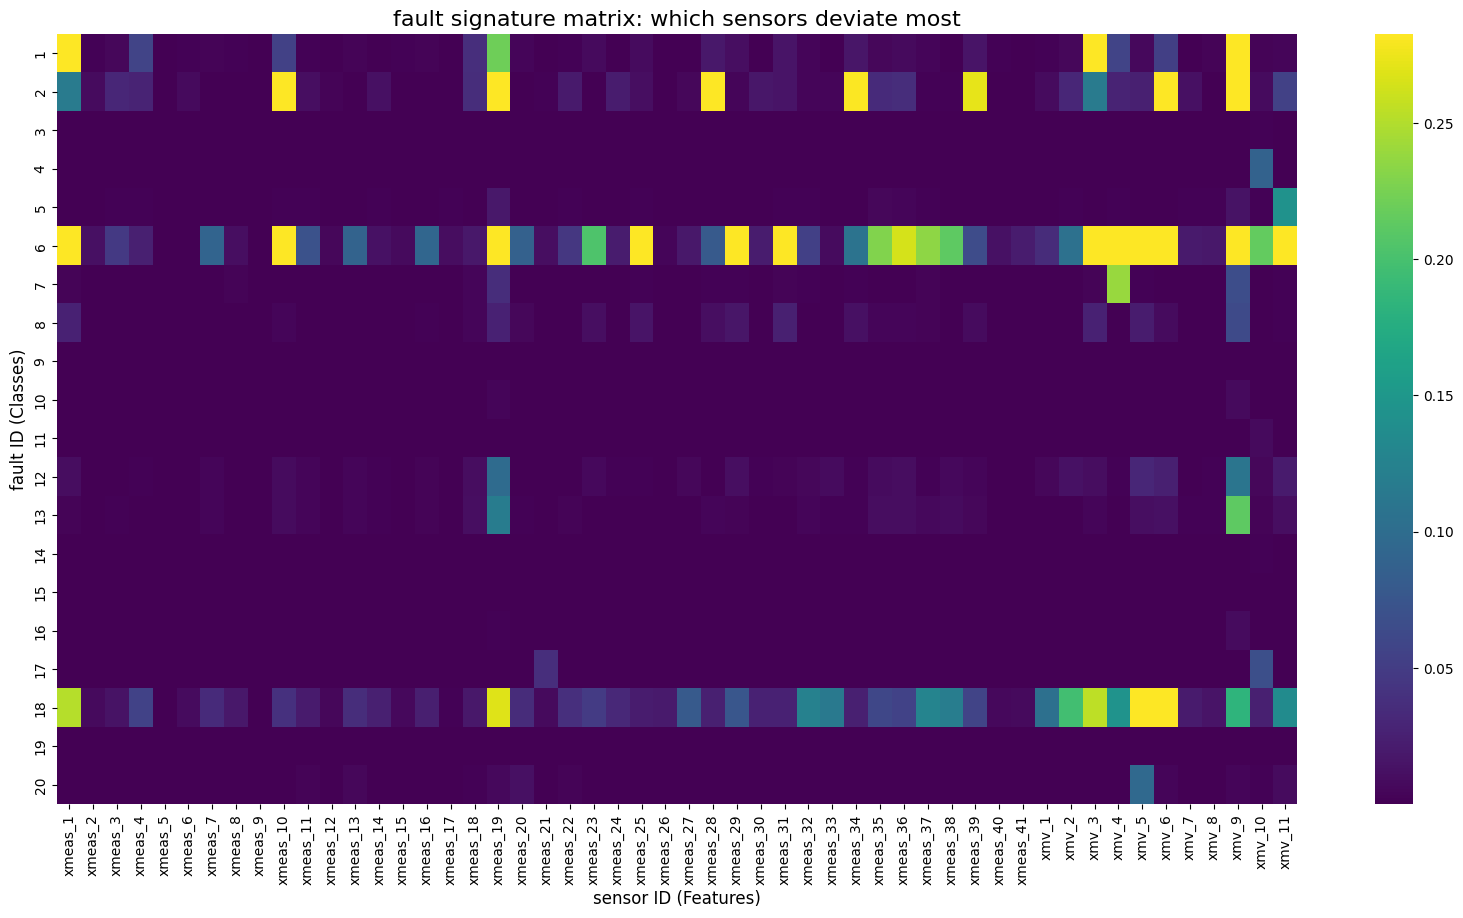

In [19]:
# calculate the baseline (Normal) Means for all 52 sensors 
# #we drop the first 3 columns (ID columns) to get just the sensor data 
normal_means = df_train_nonfaulty.drop(columns=['faultNumber', 'simulationRun', 'sample']).mean() 
# storage dataframe for deviations 
# rows are faults (1-20), cols are Sensors (1-52) 
deviation_matrix = pd.DataFrame(index=range(1, 21), columns=normal_means.index) 
# loops through each fault (1-20) and calculate deviation 
# geting data for this specific fault 
for f_id in range(1, 21): 
    fault_data = df_train_faulty[df_train_faulty['faultNumber'] == f_id]
    # calculates the mean for this fault    
    fault_means = fault_data.drop(columns=['faultNumber', 'simulationRun', 'sample']).mean()        
    # Calculate Absolute % Deviation (Normalized so we can compare Temp vs Pressure)    
    # formula: |(fault_mean - normal_mean) / normal_mean|    
    # also adding a small epsilon (1e-6) to avoid division by zero    
    deviation = abs((fault_means - normal_means) / (normal_means + 1e-6))     
    deviation_matrix.loc[f_id] = deviation 
     
deviation_matrix = deviation_matrix.astype(float) 
plt.figure(figsize=(20, 10)) 
sns.heatmap(deviation_matrix, cmap='viridis', robust=True) 
plt.title("fault signature matrix: which sensors deviate most", fontsize=16) 
plt.xlabel("sensor ID (Features)", fontsize=12) 
plt.ylabel("fault ID (Classes)", fontsize=12) 
plt.show()

*Insight: This plot shows which sensor variable is the best measure for identifying a particular fault.*

## Bivariate Process Dynamics (Fault Difficulty)
Not all faults are easy to detect. Some cause massive shifts in the mean (easy), while others hide within the normal variance of the process (stealth faults).

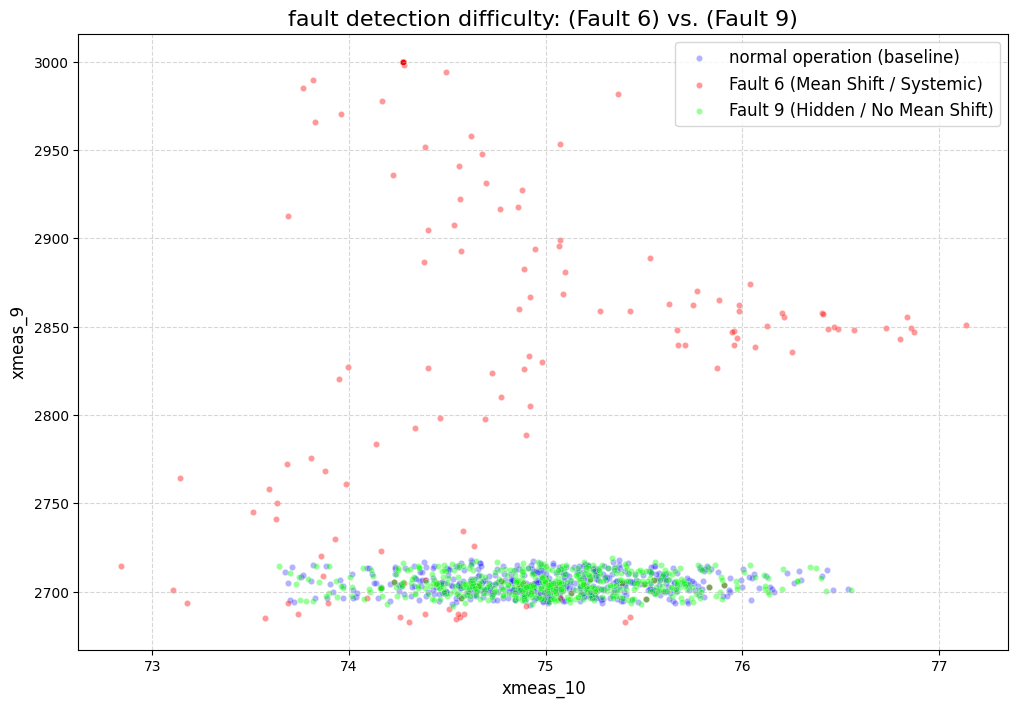

In [20]:
x_col = df_train_nonfaulty.columns[10]  # xmeas_10 
y_col = df_train_nonfaulty.columns[9]  # xmeas_9 
# filter data (Simulation Run 1) 
normal_data = df_train_nonfaulty[df_train_nonfaulty['simulationRun'] == 1] 
fault_6_data = df_train_faulty[(df_train_faulty['faultNumber'] == 6) & (df_train_faulty['simulationRun'] == 1)] 
# fault 9 is the one with no mean shift, so it will likely overlap with the normal data 
fault_9_data = df_train_faulty[(df_train_faulty['faultNumber'] == 9) & (df_train_faulty['simulationRun'] == 1)]
plt.figure(figsize=(12, 8))  
sns.scatterplot(x=normal_data[x_col], y=normal_data[y_col], color='blue', alpha=0.3, s=20, label='normal operation (baseline)') # fault 6 
sns.scatterplot(x=fault_6_data[x_col], y=fault_6_data[y_col], color='red', alpha=0.4, s=20, label='Fault 6 (Mean Shift / Systemic)') #fault 9
sns.scatterplot(x=fault_9_data[x_col], y=fault_9_data[y_col], color='lime', alpha=0.4, s=20, label='Fault 9 (Hidden / No Mean Shift)') 
plt.title(f"fault detection difficulty: (Fault 6) vs. (Fault 9)", fontsize=16) 
plt.xlabel("xmeas_10", fontsize=12) 
plt.ylabel("xmeas_9", fontsize=12) 
plt.legend(fontsize=12) 
plt.grid(True, linestyle='--', alpha=0.5) 
plt.show()

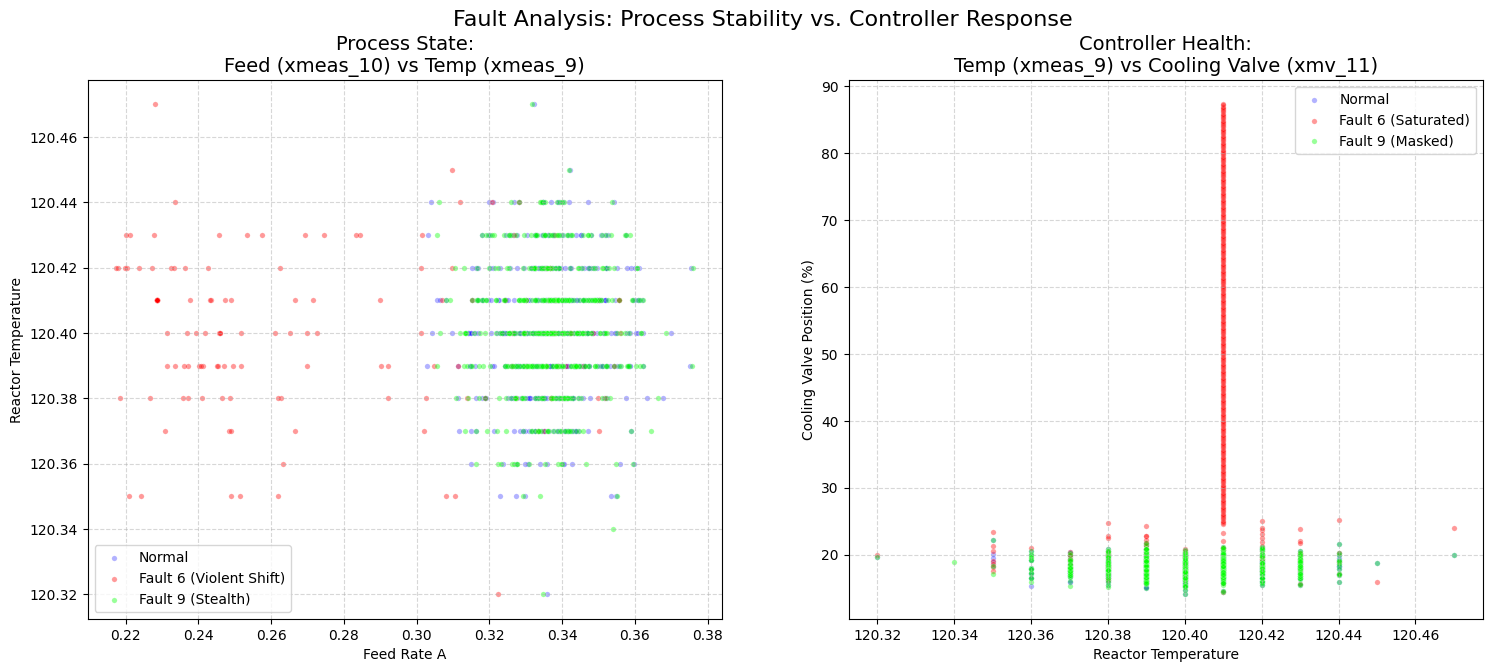

In [21]:
col_feed = [c for c in df_train_nonfaulty.columns if 'xmeas_10' in c][0]  
col_temp = [c for c in df_train_nonfaulty.columns if 'xmeas_9' in c][0] 
col_valve = [c for c in df_train_nonfaulty.columns if 'xmv_11' in c][0] 

# Filter for a single simulation run to trace a continuous timeline
run_id = 1 
normal_data = df_train_nonfaulty[df_train_nonfaulty['simulationRun'] == run_id] 
fault_6_data = df_train_faulty[(df_train_faulty['faultNumber'] == 6) & (df_train_faulty['simulationRun'] == run_id)] 
fault_9_data = df_train_faulty[(df_train_faulty['faultNumber'] == 9) & (df_train_faulty['simulationRun'] == run_id)] 

fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 
fig.suptitle('Fault Analysis: Process Stability vs. Controller Response', fontsize=16) 

# Plot 1: Process Stability
sns.scatterplot(ax=axes[0], x=normal_data[col_feed], y=normal_data[col_temp], color='blue', alpha=0.3, s=15, label='Normal') 
sns.scatterplot(ax=axes[0], x=fault_6_data[col_feed], y=fault_6_data[col_temp], color='red', alpha=0.4, s=15, label='Fault 6 (Violent Shift)') 
sns.scatterplot(ax=axes[0], x=fault_9_data[col_feed], y=fault_9_data[col_temp], color='lime', alpha=0.4, s=15, label='Fault 9 (Stealth)') 
axes[0].set_title(f'Process State:\nFeed ({col_feed}) vs Temp ({col_temp})', fontsize=14) 
axes[0].set_xlabel("Feed Rate A") 
axes[0].set_ylabel("Reactor Temperature") 
axes[0].grid(True, linestyle='--', alpha=0.5) 
axes[0].legend() 

# Plot 2: Controller Saturation 
sns.scatterplot(ax=axes[1], x=normal_data[col_temp], y=normal_data[col_valve], color='blue', alpha=0.3, s=15, label='Normal') 
sns.scatterplot(ax=axes[1], x=fault_6_data[col_temp], y=fault_6_data[col_valve], color='red', alpha=0.4, s=15, label='Fault 6 (Saturated)') 
sns.scatterplot(ax=axes[1], x=fault_9_data[col_temp], y=fault_9_data[col_valve], color='lime', alpha=0.4, s=15, label='Fault 9 (Masked)') 
axes[1].set_title(f'Controller Health:\nTemp ({col_temp}) vs Cooling Valve ({col_valve})', fontsize=14) 
axes[1].set_xlabel("Reactor Temperature") 
axes[1].set_ylabel("Cooling Valve Position (%)") 
axes[1].grid(True, linestyle='--', alpha=0.5) 
axes[1].legend()

*Insight: Fault 6 is a 'violent' fault that immediately shifts the process out of normal bounds and saturates the controller valves. Fault 9, however, is a 'stealth' fault; it overlaps entirely with normal operation, meaning a simple threshold model will fail to detect it. This justifies the need for advanced ML modeling.*

# Time-Series Visualization
The TEP data is sequentially sampled over time, hence, we must visualize how an anomaly physically appears as the time steps progress.

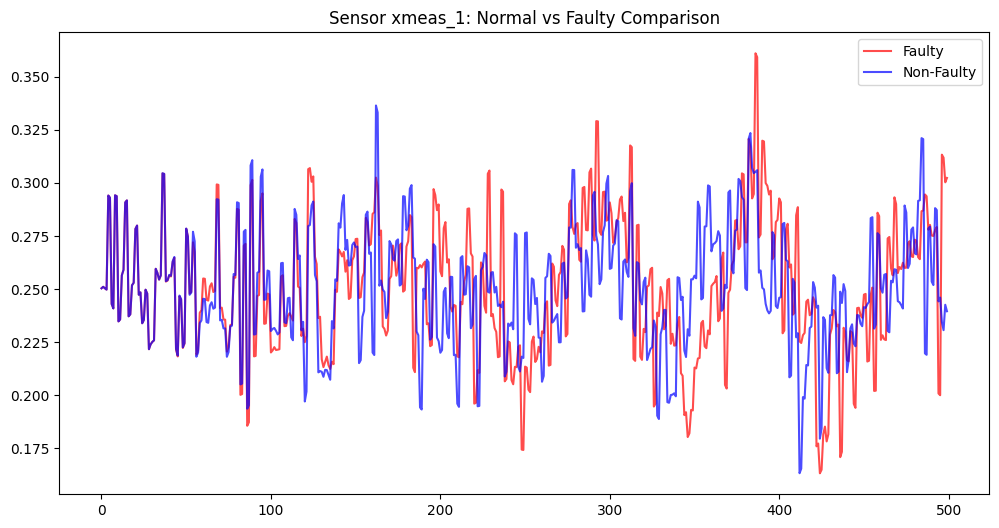

In [22]:
plt.figure(figsize=(12, 6))

# plotting a sample of Faulty data
plt.plot(df_train_faulty[df_train_faulty['faultNumber'] == 20]['xmeas_1'].iloc[:500].values, label='Faulty', color="red", alpha=0.7)

# plotting a sample of Non-Faulty data
plt.plot(df_train_nonfaulty[df_train_nonfaulty['faultNumber'] == 0]['xmeas_1'].iloc[:500].values, label='Non-Faulty', color='blue', alpha=0.7)

plt.title("Sensor xmeas_1: Normal vs Faulty Comparison")
plt.legend()
plt.show()

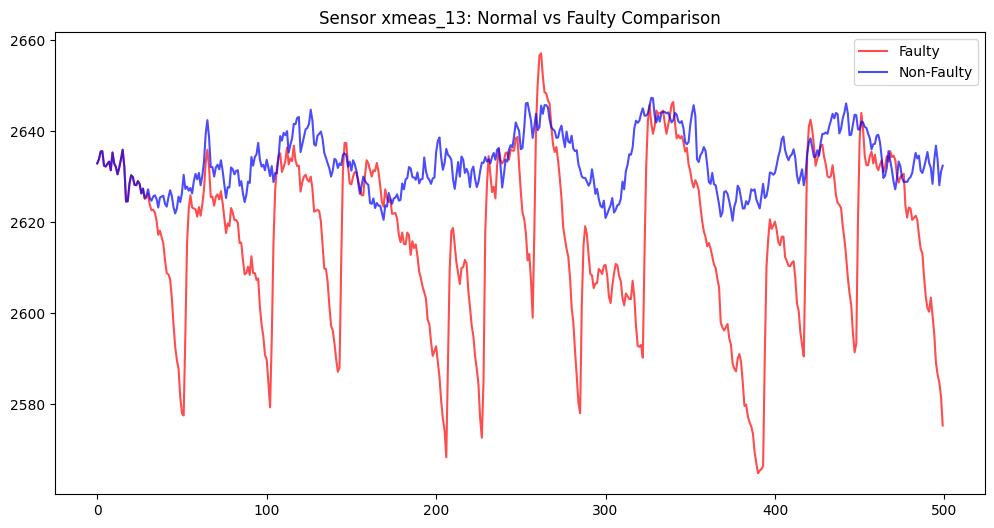

In [23]:
plt.figure(figsize=(12, 6))

# plotting a sample of Faulty data
plt.plot(df_train_faulty[df_train_faulty['faultNumber'] == 20]['xmeas_13'].iloc[:500].values, label='Faulty', color="red", alpha=0.7)

# plotting a sample of Non-Faulty data
plt.plot(df_train_nonfaulty[df_train_nonfaulty['faultNumber'] == 0]['xmeas_13'].iloc[:500].values, label='Non-Faulty', color='blue', alpha=0.7)

plt.title("Sensor xmeas_13: Normal vs Faulty Comparison")
plt.legend()
plt.show()

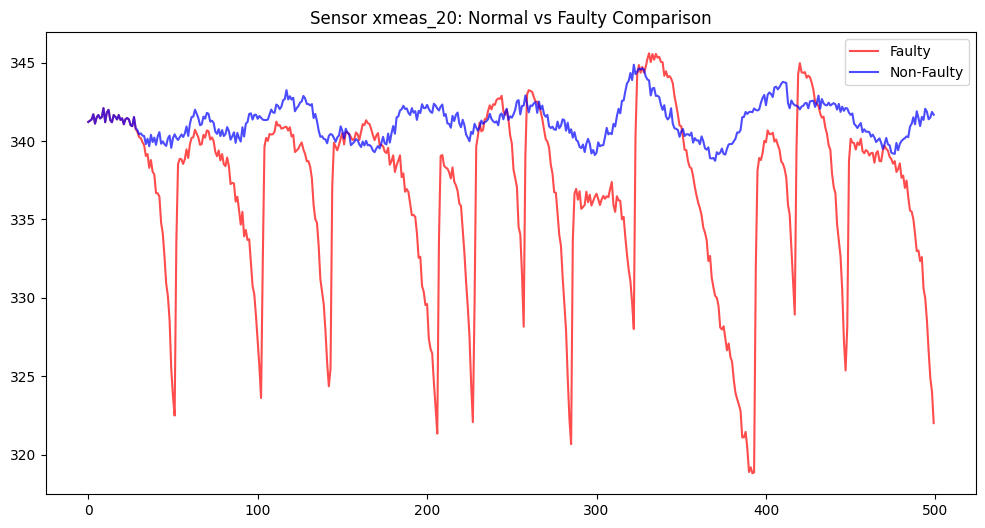

In [24]:
plt.figure(figsize=(12, 6))

# plotting a sample of Faulty data
plt.plot(df_train_faulty[df_train_faulty['faultNumber'] == 20]['xmeas_20'].iloc[:500].values, label='Faulty', color="red", alpha=0.7)

# plotting a sample of Non-Faulty data
plt.plot(df_train_nonfaulty[df_train_nonfaulty['faultNumber'] == 0]['xmeas_20'].iloc[:500].values, label='Non-Faulty', color='blue', alpha=0.7)

plt.title("Sensor xmeas_20: Normal vs Faulty Comparison")
plt.legend()
plt.show()

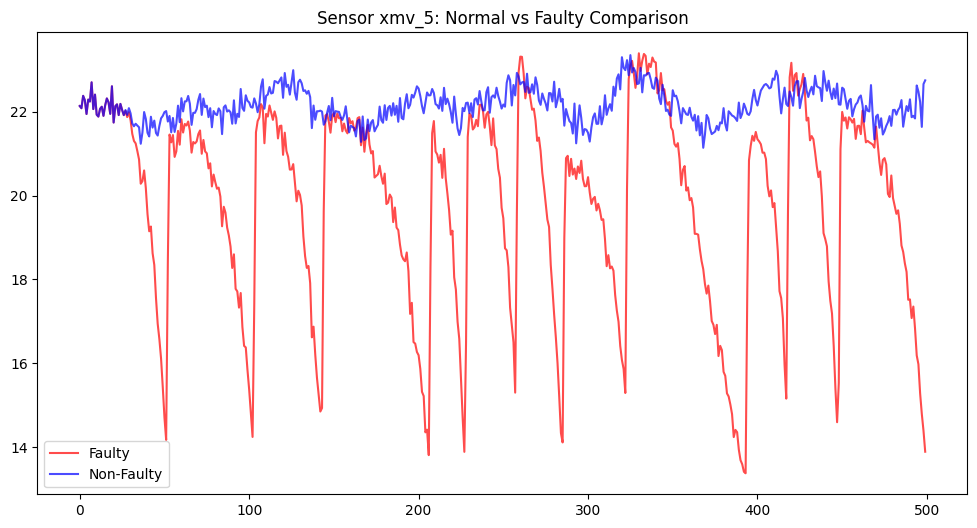

In [25]:
plt.figure(figsize=(12, 6))

# plotting a sample of Faulty data
plt.plot(df_train_faulty[df_train_faulty['faultNumber'] == 20]['xmv_5'].iloc[:500].values, label='Faulty', color="red", alpha=0.7)

# plotting a sample of Non-Faulty data
plt.plot(df_train_nonfaulty[df_train_nonfaulty['faultNumber'] == 0]['xmv_5'].iloc[:500].values, label='Non-Faulty', color='blue', alpha=0.7)

plt.title("Sensor xmv_5: Normal vs Faulty Comparison")
plt.legend()
plt.show()

*Insight: These time series plot show that while some sensors compeletely overlap for both faulty and non-faulty measures, some sensors show a distinguishable mean shift for faulty and non-faulty measures making it easier to detect anamolies.*